# Customer Churn Prediction and Analysis Using Machine Learning

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import joblib

In [8]:
# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("Telco-Customer-Churn.csv")

print(df.head())
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [9]:
# ==============================
#  3. Data Preprocessing
# ==============================

# Drop customerID
df.drop("customerID", axis=1, inplace=True)

# Fix TotalCharges (contains blanks)
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Fill missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Convert target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


C:\Users\Bhaskar jha\AppData\Local\Temp\ipykernel_11308\3379413172.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


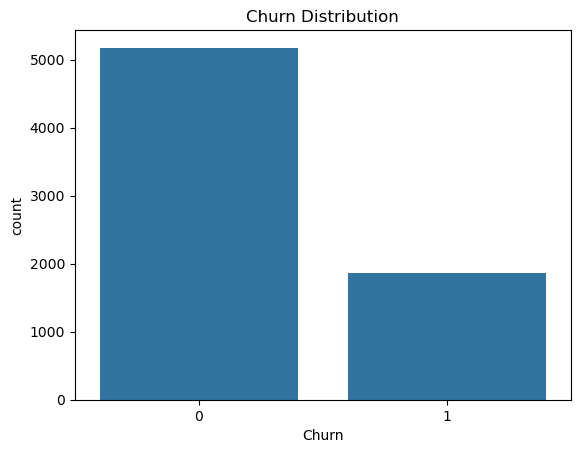

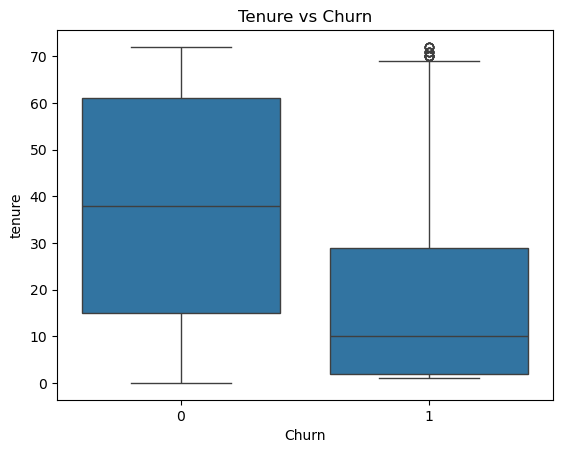

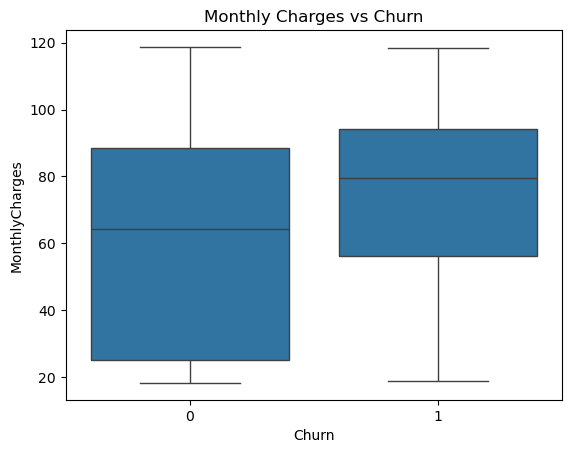

In [16]:
# ==============================
#  4. EDA (Important)
# ==============================

# Churn distribution
plt.figure()
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.savefig("churn_distribution.png")

# Tenure vs churn
plt.figure()
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.savefig("tenure_vs_churn.png")

# MonthlyCharges vs churn
plt.figure()
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.savefig("monthly_vs_churn.png")

Epoch 1/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6735 - loss: 0.6220 - val_accuracy: 0.6987 - val_loss: 0.5993
Epoch 2/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6789 - loss: 0.6121 - val_accuracy: 0.7258 - val_loss: 0.5757
Epoch 3/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6776 - loss: 0.6125 - val_accuracy: 0.7095 - val_loss: 0.5875
Epoch 4/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6774 - loss: 0.6129 - val_accuracy: 0.7234 - val_loss: 0.5805
Epoch 5/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6870 - loss: 0.6123 - val_accuracy: 0.7011 - val_loss: 0.5873
Epoch 6/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6913 - loss: 0.6049 - val_accuracy: 0.7252 - val_loss: 0.5753
Epoch 7/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6986 - loss: 0.6001 - val_accuracy: 0.7271 - val_loss: 0.5710
Epoch 8/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6832 - loss: 0.6070 - val_accuracy: 0.

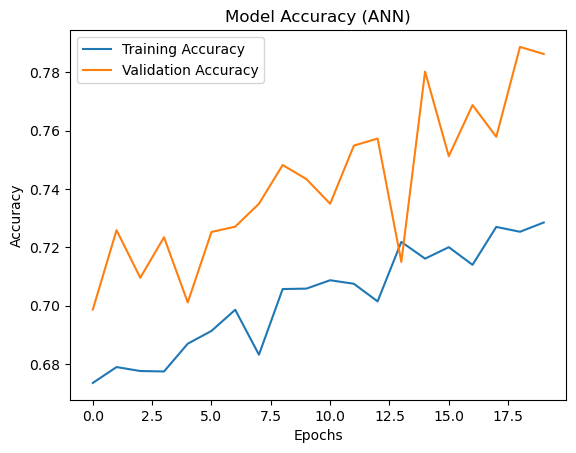

In [26]:
# ==============================
# 🔹 Accuracy Graph (ANN)
# ==============================

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy (ANN)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("accuracy_graph.png")
plt.show()

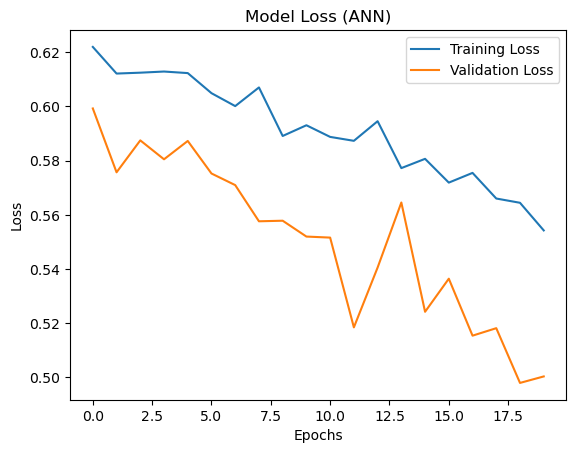

In [28]:
# Loss Graph
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss (ANN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig("loss_graph.png")
plt.show()

In [17]:
# ==============================
#  5. Encode Categorical Columns
# ==============================

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [18]:
# ==============================
#  6. Feature & Target
# ==============================

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [19]:
# ==============================
#  7. Handle Imbalance
# ==============================

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [20]:
# ==============================
#  8. Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

In [15]:
# ==============================
# 9. Models
# ==============================

#  Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

#  Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#  ANN
model = Sequential()

model.add(Dense(128, activation="relu", input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

C:\Users\Bhaskar jha\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Bhaskar jha\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5562 - loss: 39.4600 - val_accuracy: 0.6552 - val_loss: 1.2759
Epoch 2/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5825 - loss: 2.9266 - val_accuracy: 0.6431 - val_loss: 0.6680
Epoch 3/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5720 - loss: 0.9856 - val_accuracy: 0.6377 - val_loss: 0.6569
Epoch 4/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5689 - loss: 0.8128 - val_accuracy: 0.6365 - val_loss: 0.6427
Epoch 5/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5760 - loss: 0.7395 - val_accuracy: 0.5996 - val_loss: 0.6567
Epoch 6/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5888 - loss: 0.7137 - val_accuracy: 0.6147 - val_loss: 0.6445
Epoch 7/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6004 - loss: 0.6935 - val_accuracy: 0.6208 - val_loss: 0.6424
Epoch 8/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6054 - loss: 0.6789 - val_accuracy: 0

In [21]:
# ==============================
# 🔹 10. Evaluation
# ==============================

# Logistic Regression
y_pred_lr = lr.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))

# Random Forest
y_pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

# ANN
loss, acc = model.evaluate(X_test, y_test)
print("ANN Accuracy:", acc)

print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))

LR Accuracy: 0.8111111111111111
RF Accuracy: 0.8623188405797102
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7159 - loss: 0.5844 
ANN Accuracy: 0.7159420251846313

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1021
           1       0.87      0.86      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



In [24]:
# -------- 9. MODEL SUMMARY --------
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,645 (127.52 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,764 (85.02 KB)

In [22]:
# ==============================
# 11. Save Model
# ==============================

joblib.dump(rf, "churn_model.pkl")

['churn_model.pkl']